# Error Correction Model Parameter Estimation

The Error Correction for two $I(1)$ processes, $X_t$ and $Y_t$ the ECM is given by,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{1}
$

where $\nu_t \sim \text{Normal}(0, \sigma^2)$.</br>

To perform parameter estimation let,

$
\begin{align}
\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}
\end{align}
\tag{2}
$

OLS is used to used to estimate $\beta$ to obtain,

$
\begin{align}
\hat{\varepsilon}_{t-1} = Y_{t-1} - \hat{\beta} X_{t-1}
\end{align}
\tag{3}
$

where $\hat{\beta}$ is the OLS estimate of $\beta$. Next the ADF test is used to test $\hat{\varepsilon}_{t-1}$ for stationarity. Replacing the $Y_{t-1} - \beta X_{t-1}$ term in the ECM with $\hat{\varepsilon}_{t-1}$ gives

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \hat{\varepsilon}_{t-1} + \nu_t
\end{align}
\tag{4}
$

Next $\gamma$ and $\lambda$ can be estimated using OLS. This is called the Granger two-step process.

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, ecm_beta
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

### $\beta$ Estimation

In [3]:
φ = 0.5
λ = -0.5
γ = 0.5
β = 0.5
npts = 1000

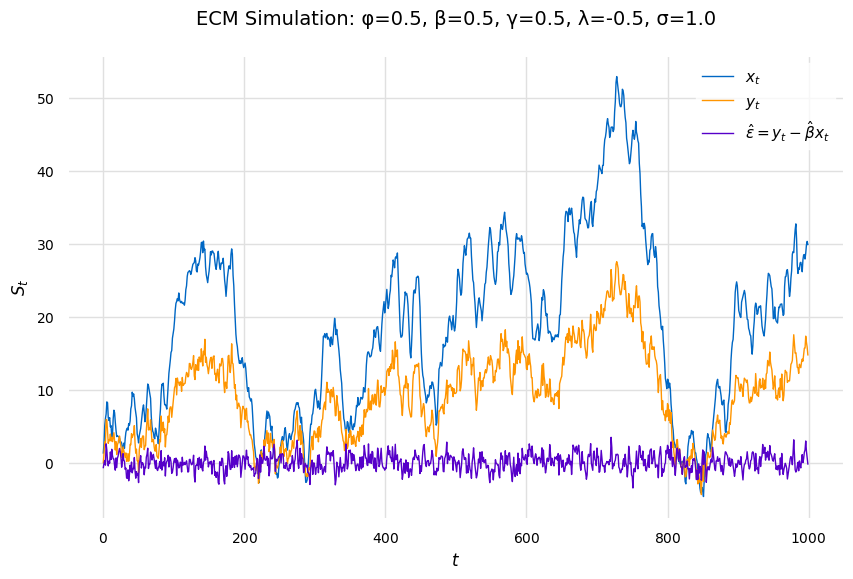

In [4]:
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

#### Residual Stationarity

In [5]:
εt = yt - β * xt
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.8349      │
├────────────────┼───────────────┤
│ pvalue         │   3.52561e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 999           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [8]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "4334fa51-d772-4e5c-a9ec-ff668ea26e43",
                "label": "$t$",
                "value": -17.579274329179935
            },
            "pval": {
                "test_id": "4334fa51-d772-4e5c-a9ec-ff668ea26e43",
                "label": "$p-value$",
                "value": 7.588687661854109e-29
            },
            "params": [],
            "sig": {
                "test_id": "4334fa51-d772-4e5c-a9ec-ff668ea26e43",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "4334fa51-d772-4e5c-a9ec-ff668ea26e43",
                "label": "$t_L$",
                "value": -2.5679816723029334
            },
            "upper": null,
            "test_id": "4334fa51-d772-4e5c-a9ec-ff668ea26e43"
        },
  

In [7]:
result, beta_result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                 3.022e+04
Date:                Sat, 18 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:16:08   Log-Likelihood:                -1522.4
No. Observations:                1000   AIC:                             3049.
Df Residuals:                     998   BIC:                             3059.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0021      0.064     -0.032      0.974      -0.128       0.124
x1             0.5023      0.003    173.851      0.000       0.497       0.508
==============================================================================
Omnibus:                        0.310   Durbin-Watson:                   1.050
Prob(Omnibus):                  0.856   Jarque-Bera (JB):                0.395
Skew:                           0.022   Prob(JB):                        0.821
Kurtosis:                       2.913   Cond. No.                         40.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
print(beta_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.002501525726257609,
      "err": 0.03752564906885527,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "bc342055-47d8-4997-8550-ff72c2da3c36",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.4881915115524709,
         "err": 0.0027874057113893547,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "bc342055-47d8-4997-8550-ff72c2da3c36",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9684901965800078,
   "param_transforms": [
      {
         "param": {
            "est": 0.4881915115524709,
            "err": 0.0027874057113893547,
            "est_label": "$\\hat{\\beta}$",
            "err_label": "$\\sigma_{\\hat{\\beta}}$",
            "row": 0,
            "column": 0,
            

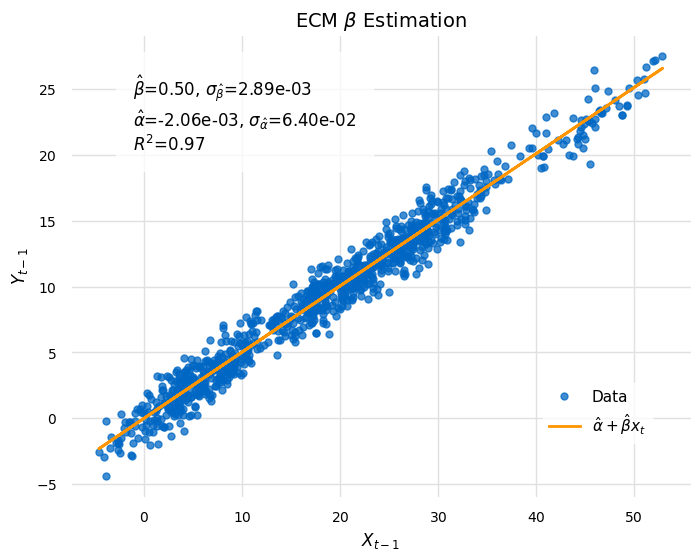

In [8]:
ecm_beta(yt, beta_result_model, xt)

### $\gamma$ and $\lambda$ Estimation

In [12]:
result, gamma_lambda_result_model = ecm.compute_gamma_lambda_estimate(yt, xt, beta_result_model.params[0].est)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     273.4
Date:                Sun, 17 Dec 2023   Prob (F-statistic):           2.24e-95
Time:                        14:20:07   Log-Likelihood:                -1413.6
No. Observations:                 999   AIC:                             2833.
Df Residuals:                     996   BIC:                             2848.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.032     -0.026      0.979      -0.063       0.061
x1             0.4788      0.028     17.030      0.000       0.424       0.534
x2            -0.4801      0.027    -17.637      0.000      -0.534      -0.427
==============================================================================
Omnibus:                        3.630   Durbin-Watson:                   1.956
Prob(Omnibus):                  0.163   Jarque-Bera (JB):                3.488
Skew:                           0.136   Prob(JB):                        0.175
Kurtosis:                       3.097   Cond. No.                         1.21
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
print(gamma_lambda_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.1303051355044204,
      "err": 0.03268063586795058,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "6b735f70-c8f3-4c15-8ced-5b6a64d5cb64",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.5082866064041589,
         "err": 0.02793003366623465,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "6b735f70-c8f3-4c15-8ced-5b6a64d5cb64",
         "param_type": "OLS_PARAM"
      },
      {
         "est": -0.47795636368020106,
         "err": 0.027072182865013193,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "6b735f70-c8f3-4c15-8ced-5b6a64d5cb64",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.40450516358431876,
   "param_transforms": [
      {
      